<a href="https://colab.research.google.com/github/2023atharvvichare/Machine-Learning/blob/main/ML_Experiment_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# STEP 1: Download & load

In [4]:
path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")
# many Kaggle mirrors include both red and white; if you have a merged file use that instead.
# Example file names: 'winequality-red.csv' or 'winequality-white.csv'
# Here we'll try to read a merged CSV if present, else fallback to red.
import os
possible_files = os.listdir(path)
print("Files in dataset folder:", possible_files)

# prefer a merged dataset if available
if "winequality-red.csv" in possible_files and "winequality-white.csv" in possible_files:
    df_red = pd.read_csv(os.path.join(path, "winequality-red.csv"), sep=';')
    df_white = pd.read_csv(os.path.join(path, "winequality-white.csv"), sep=';')
    df_red['color'] = 'red'
    df_white['color'] = 'white'
    df = pd.concat([df_red, df_white], ignore_index=True)
else:
    # try merged file or single file
    csvs = [f for f in possible_files if f.endswith('.csv')]
    # The separator should be ',' instead of ';'
    df = pd.read_csv(os.path.join(path, csvs[0]), sep=',')

print("Dataset shape:", df.shape)
print(df.columns.tolist())
df.head()

Using Colab cache for faster access to the 'red-wine-quality-cortez-et-al-2009' dataset.
Files in dataset folder: ['winequality-red.csv']
Dataset shape: (1599, 12)
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# STEP 2: Preprocessing

In [5]:
# No missing values in canonical wine datasets, but check:
print("Missing values per column:\n", df.isnull().sum())

# For visualization, optionally treat 'quality' as categorical or bin it
# Option A: classification into low/medium/high by binning quality
# (quality typically 0-10; common split: <=5 low, 6 medium, >=7 high)
df['quality_label'] = pd.cut(df['quality'], bins=[-1,5,6,10], labels=['low','medium','high'])

# Features and target
feature_cols = [c for c in df.columns if c not in ['quality', 'quality_label', 'color']]
X = df[feature_cols].copy()
y = df['quality_label']  # using classification example

# Standardize numeric features before PCA/t-SNE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Missing values per column:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


# STEP 3: Exploratory visuals

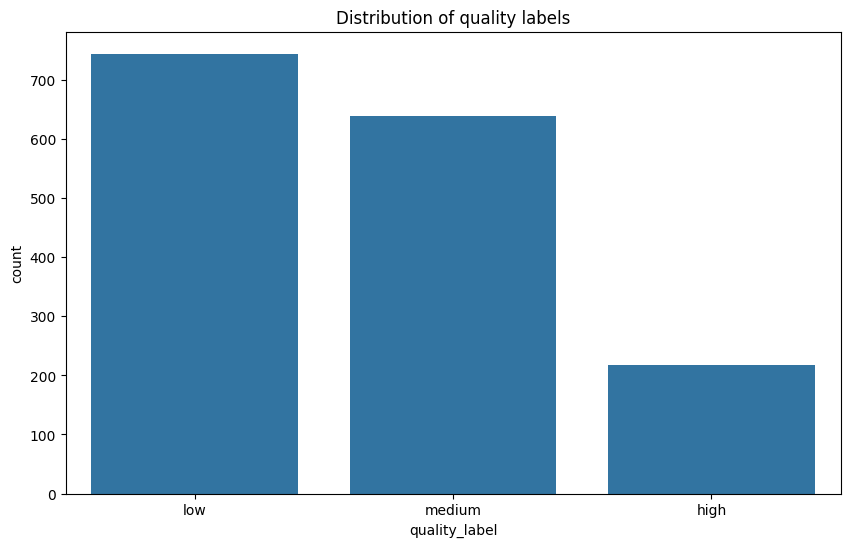

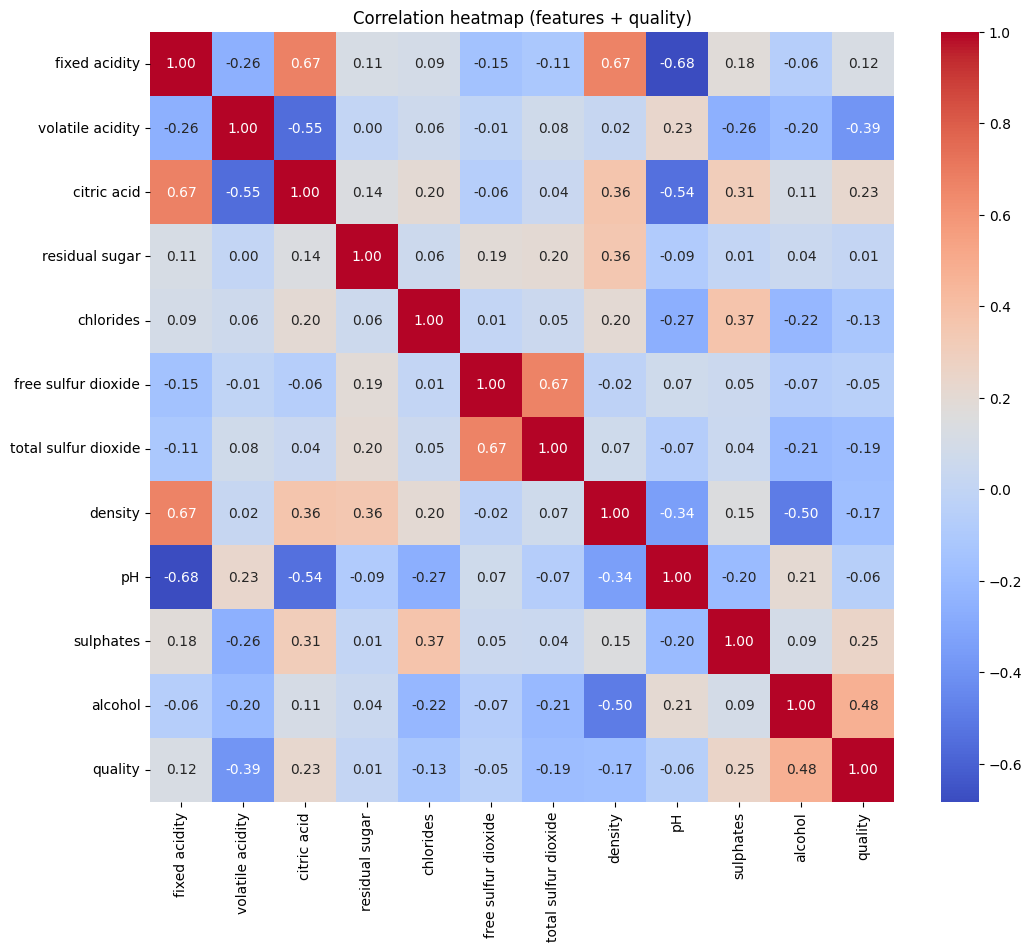

In [6]:
plt.figure(figsize=(10,6))
sns.countplot(x='quality_label', data=df, order=['low','medium','high'])
plt.title("Distribution of quality labels")
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(df[feature_cols + ['quality']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation heatmap (features + quality)")
plt.show()

# STEP 4: PCA

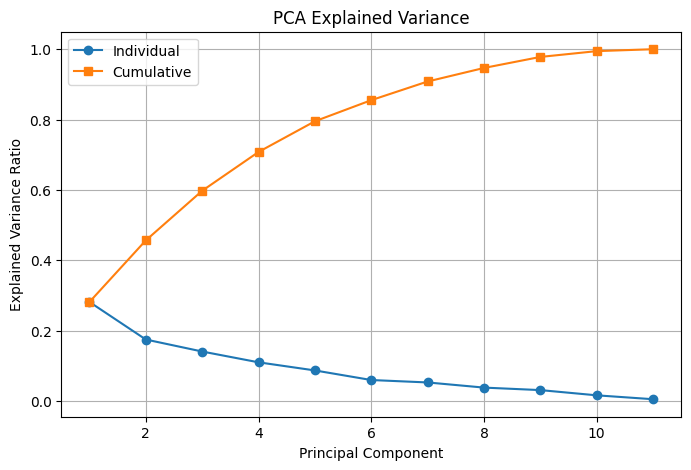

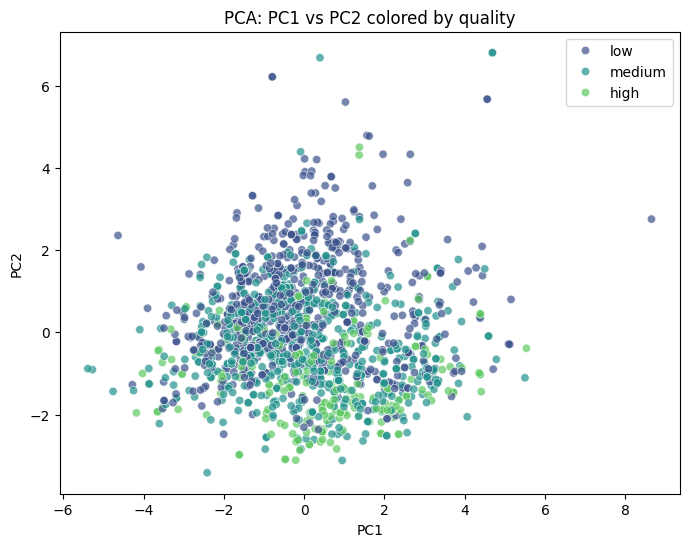

In [7]:
pca = PCA()
X_pca_all = pca.fit_transform(X_scaled)

# Explained variance plot
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(explained)+1), explained, marker='o', label='Individual')
plt.plot(np.arange(1, len(explained)+1), cum_explained, marker='s', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

# Scatter of first 2 PCs colored by quality_label
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca_all[:,0], y=X_pca_all[:,1], hue=df['quality_label'], palette='viridis', alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA: PC1 vs PC2 colored by quality')
plt.legend()
plt.show()

# STEP 5: t-SNE (2D)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


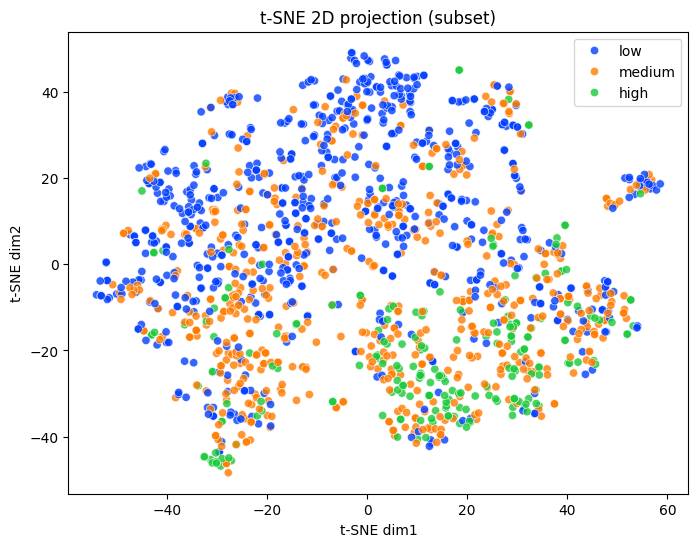

In [8]:
# t-SNE is slow on large datasets; we can subsample for visualization
subset_size = 1500
rng = np.random.RandomState(42)
idx = rng.choice(len(X_scaled), size=min(subset_size, len(X_scaled)), replace=False)
X_sub = X_scaled[idx]
y_sub = df['quality_label'].values[idx]

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_sub)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y_sub, palette='bright', alpha=0.8)
plt.title('t-SNE 2D projection (subset)')
plt.xlabel('t-SNE dim1'); plt.ylabel('t-SNE dim2')
plt.legend()
plt.show()

# STEP 6: Fit & Test — classification on original vs PCA features

Number of PCA components to reach ~90% variance: 7
Original features — Accuracy: 0.75625
Original features — F1 (macro): 0.7192213423831072

PCA features — Accuracy: 0.725
PCA features — F1 (macro): 0.7041847041847041

Classification report (Original features):
               precision    recall  f1-score   support

        high       0.69      0.56      0.62        43
         low       0.80      0.85      0.82       149
      medium       0.72      0.72      0.72       128

    accuracy                           0.76       320
   macro avg       0.74      0.71      0.72       320
weighted avg       0.75      0.76      0.75       320


Classification report (PCA features):
               precision    recall  f1-score   support

        high       0.68      0.63      0.65        43
         low       0.75      0.81      0.78       149
      medium       0.70      0.66      0.68       128

    accuracy                           0.72       320
   macro avg       0.71      0.70      0.70 

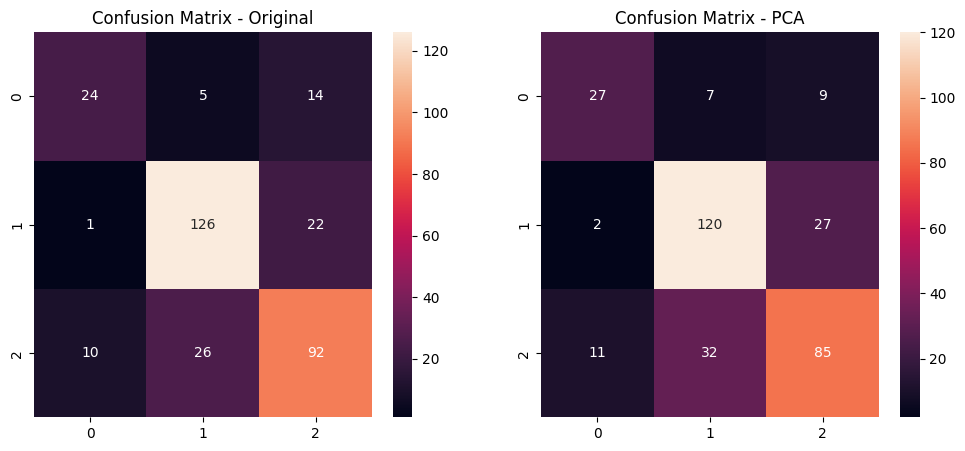

In [9]:
# We'll compare RandomForestClassifier performance on:
# a) original scaled features
# b) PCA-reduced features (choose k components that explain ~90% variance)

# choose k by cumulative explained variance (>=0.90)
k = np.searchsorted(cum_explained, 0.90) + 1
print(f"Number of PCA components to reach ~90% variance: {k}")

X_pca_k = X_pca_all[:, :k]

# Train/test split (stratify by label)
X_train_ori, X_test_ori, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca_k, y, test_size=0.2, stratify=y, random_state=42)

# Model: Random Forest
from sklearn.ensemble import RandomForestClassifier
clf_ori = RandomForestClassifier(n_estimators=200, random_state=42)
clf_pca = RandomForestClassifier(n_estimators=200, random_state=42)

clf_ori.fit(X_train_ori, y_train)
clf_pca.fit(X_train_pca, y_train)

y_pred_ori = clf_ori.predict(X_test_ori)
y_pred_pca = clf_pca.predict(X_test_pca)

print("Original features — Accuracy:", accuracy_score(y_test, y_pred_ori))
print("Original features — F1 (macro):", f1_score(y_test, y_pred_ori, average='macro'))
print("\nPCA features — Accuracy:", accuracy_score(y_test, y_pred_pca))
print("PCA features — F1 (macro):", f1_score(y_test, y_pred_pca, average='macro'))

print("\nClassification report (Original features):\n", classification_report(y_test, y_pred_ori))
print("\nClassification report (PCA features):\n", classification_report(y_test, y_pred_pca))

# Confusion matrices
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.heatmap(confusion_matrix(y_test, y_pred_ori), annot=True, fmt='d', ax=axes[0])
axes[0].set_title('Confusion Matrix - Original')
sns.heatmap(confusion_matrix(y_test, y_pred_pca), annot=True, fmt='d', ax=axes[1])
axes[1].set_title('Confusion Matrix - PCA')
plt.show()